# ICBHI Respiratory Sound Classification — Inspection Notebook (v2 — Focal Loss)

## Goal
Run the **exact model from the paper repo** with **Focal Loss + class weighting** replacing
the default CrossEntropyLoss, to improve recall on minority classes (Crackle, Wheeze, Both).

## Key change vs v1
| v1 | v2 |
|----|----|
| `CrossEntropyLoss()` — treats all classes equally | `FocalLoss(alpha, gamma=2)` — down-weights easy Normal examples, focuses on hard anomalies |
| Recall macro: 48.12% | Target: ≥ 55% |
| ICBHI score: 65.72% | Target: ≥ 68% (paper baseline) |

## Structure
| Cell | Purpose |
|------|---------|
| 1 | Environment check |
| 2 | Install dependencies |
| 3 | Clone repo (exact paper code) |
| 4 | Dataset setup |
| 5 | Preprocessing (cyclic pad → 8 s @ 16 kHz) |
| 6 | **Persistent-checkpoint setup** — one-time Kaggle Dataset creation |
| 7 | **Training** — Focal Loss + WeightedSampler + SAM |
| 8 | Learning curves — Jtrain vs Jcv vs human-level baseline (bias/variance) |
| 9 | Test-set inference (run once, results saved to disk) |
| 10 | Threshold tuning on CV set |
| 11 | Full metrics — accuracy, precision, recall, F1, specificity, ICBHI score |
| 12 | Deep error analysis — where and why the model fails |


In [2]:
import torch, os, sys

print("="*55)
print("ENVIRONMENT CHECK")
print("="*55)
print(f"\nGPU available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU name      : {torch.cuda.get_device_name(0)}")
    print(f"GPU memory    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"\nPython  : {sys.version}")
print(f"PyTorch : {torch.__version__}")
print(f"Workdir : {os.getcwd()}")
print("\n/kaggle/input/ contents:")
!ls /kaggle/input/


ENVIRONMENT CHECK

GPU available : True
GPU name      : Tesla T4
GPU memory    : 15.6 GB

Python  : 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
PyTorch : 2.10.0+cu128
Workdir : /kaggle/working

/kaggle/input/ contents:
datasets


In [3]:
!pip install -q librosa soundfile "transformers>=4.30.0" tqdm seaborn

import librosa, soundfile, transformers, seaborn, sklearn
print("librosa      :", librosa.__version__)
print("transformers :", transformers.__version__)
print("scikit-learn :", sklearn.__version__)
print("soundfile    : OK")
print("seaborn      : OK")


librosa      : 0.11.0
transformers : 5.0.0
scikit-learn : 1.6.1
soundfile    : OK
seaborn      : OK


In [4]:
import os, sys

REPO_DIR = "/kaggle/working/ICBHI-AST-SAM"

if not os.path.exists(REPO_DIR):
    !git clone https://github.com/Atakanisik/ICBHI-AST-SAM.git {REPO_DIR}
    print("Repo cloned.")
else:
    print("Repo already present.")

os.chdir(REPO_DIR)
sys.path.insert(0, REPO_DIR)

print("\nRepo structure:")
!find . -not -path "./.git/*" -type f | sort


Cloning into '/kaggle/working/ICBHI-AST-SAM'...
remote: Enumerating objects: 34, done.
remote: Counting objects: 100% (34/34), done.
remote: Compressing objects: 100% (31/31), done.
remote: Total 34 (delta 12), reused 8 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (34/34), 17.07 KiB | 4.27 MiB/s, done.
Resolving deltas: 100% (12/12), done.
Repo cloned.

Repo structure:
./checkpoints/.gitkeep
./data/.gitkeep
./evaluate.py
./LICENSE
./preprocess.py
./README.md
./requirements.txt
./src/dataset.py
./src/__init__,py
./src/model.py
./src/sam.py
./train.py


In [5]:
import os, numpy as np

os.makedirs("data", exist_ok=True)
os.makedirs("checkpoints", exist_ok=True)

# Auto-detect the folder that contains the 920 .wav files
DATA_DIR = None
for root, dirs, files in os.walk("/kaggle/input/"):
    wavs = [f for f in files if f.endswith(".wav")]
    if len(wavs) > 100:
        DATA_DIR = root
        print(f"Found dataset: {root}  ({len(wavs)} .wav files)")
        break

if DATA_DIR is None:
    raise RuntimeError("Dataset not found in /kaggle/input/. Attach the ICBHI dataset.")

# Symlink so repo paths work
if not os.path.exists("data/ICBHI_final_database"):
    os.symlink(DATA_DIR, "data/ICBHI_final_database")
    print("Symlink created: data/ICBHI_final_database")

# Regenerate the official 60/40 patient-level split
all_files   = sorted([f.replace(".wav","") for f in os.listdir(DATA_DIR) if f.endswith(".wav")])
patient_ids = sorted(set([f.split("_")[0] for f in all_files]))
np.random.seed(42)
test_patients = set(np.random.choice(patient_ids, int(len(patient_ids)*0.4), replace=False))
TARGET_SPLIT = "data/ICBHI_Challenge_train_test.txt"
lines = [f"{f}\t{'test' if f.split('_')[0] in test_patients else 'train'}" for f in all_files]
with open(TARGET_SPLIT, "w") as fh:
    fh.write("\n".join(lines))

tr = sum(1 for l in lines if "train" in l)
te = sum(1 for l in lines if "test"  in l)
print(f"Split file written: {tr} train / {te} test")

Found dataset: /kaggle/input/datasets/eyakhlifi/icbhi-data/ICBHI_final_database  (920 .wav files)
Symlink created: data/ICBHI_final_database
Split file written: 638 train / 282 test


In [6]:
import os, numpy as np

NPZ = "/kaggle/working/ICBHI-AST-SAM/icbhi_ast_16k_8s_metadata.npz"

if os.path.exists(NPZ):
    print("NPZ already exists — skipping preprocessing.")
else:
    print("Running preprocess.py ")
    !python /kaggle/working/ICBHI-AST-SAM/preprocess.py
    print("Preprocessing done.")

raw = np.load(NPZ)
print(f"\nX_train : {raw['X_train'].shape}")
print(f"y_train : {raw['y_train'].shape}")
print(f"X_test  : {raw['X_test'].shape}")
print(f"y_test  : {raw['y_test'].shape}")

CLASS_NAMES = ["Normal","Crackle","Wheeze","Both"]
print("\nClass distribution in original train split:")
for i, n in enumerate(CLASS_NAMES):
    c = (raw["y_train"]==i).sum()
    print(f"  {n:<8}: {c:4d}  ({c/len(raw['y_train'])*100:.1f}%)")


Running preprocess.py 
🚀 Begins
100%|█████████████████████████████████████████| 920/920 [01:19<00:00, 11.53it/s]
Train : (4540, 128000), Test : (2358, 128000)
✅ Saved: icbhi_ast_16k_8s_metadata.npz
Preprocessing done.

X_train : (4540, 128000)
y_train : (4540,)
X_test  : (2358, 128000)
y_test  : (2358,)

Class distribution in original train split:
  Normal  : 2302  (50.7%)
  Crackle : 1264  (27.8%)
  Wheeze  :  637  (14.0%)
  Both    :  337  (7.4%)


## Cell 7 — Training with Focal Loss

### What changed from v1

| Component | v1 | v2 |
|-----------|----|----|
| Loss | `CrossEntropyLoss()` | `FocalLoss(alpha, gamma=2)` |
| Alpha | — | Inverse class frequency, normalized |
| Gamma | — | 2.0 (standard value from the original paper) |
| Sampler | WeightedRandomSampler | WeightedRandomSampler (unchanged) |
| Optimizer | SAM + AdamW | SAM + AdamW (unchanged) |

### Why Focal Loss helps here

The v1 model reached **Train Acc = 99.1% vs CV Acc = 81.9%** with a loss gap of **14×** (overfitting).
The root cause: `CrossEntropyLoss` treats every correctly-classified Normal sample as a full learning signal,
letting the model exploit the majority class without improving on Crackle/Wheeze/Both.

Focal Loss introduces a *modulating factor* `(1 - p_t)^gamma`:
- When the model predicts a class with high confidence (p_t → 1), the factor → 0 and the loss contribution shrinks.
- Hard examples (low p_t) retain their full gradient signal.
- Combined with `alpha` weights, rare classes (Both: 7.4% of data) get **higher weight AND are never suppressed**.

### Expected behaviour
- Recall on `Both` and `Crackle` should increase significantly.
- Overall accuracy may drop slightly (Normal recall could decrease a few %).
- ICBHI score (Se + Sp) / 2 should rise above the paper baseline of 68.10%.


In [ ]:
import os, sys, json, shutil
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from tqdm import tqdm

sys.path.insert(0, "/kaggle/working/ICBHI-AST-SAM")
from transformers import ASTFeatureExtractor
from src.dataset import ASTDataset
from src.model   import CustomAST
from src.sam     import SAM

# ──────────────────────────────────────────────────────────────
# FOCAL LOSS — replaces CrossEntropyLoss
# ──────────────────────────────────────────────────────────────
class FocalLoss(nn.Module):
    """
    Focal Loss (Lin et al., 2017) with per-class alpha weighting.

    FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)

    Args:
        alpha  : 1-D tensor of per-class weights (shape = num_classes).
                 Set proportional to inverse class frequency so rare
                 classes (Crackle, Wheeze, Both) get higher weight.
        gamma  : focusing parameter (default 2.0).
                 gamma=0  → reduces to weighted cross-entropy.
                 gamma=2  → down-weights easy examples by (1-p)^2,
                            forcing the model to focus on hard ones.
    Why this fixes the recall problem:
        With CrossEntropyLoss the model learns to confidently predict
        "Normal" (majority class) because it sees ~51% Normal samples
        even after WeightedSampler. The (1-p)^gamma factor penalises
        high-confidence correct predictions, so the model cannot coast
        on Normal and is forced to improve on Crackle/Wheeze/Both.
    """
    def __init__(self, alpha: torch.Tensor, gamma: float = 2.0):
        super().__init__()
        self.register_buffer("alpha", alpha)
        self.gamma = gamma

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        # Standard CE loss per sample (unreduced)
        ce   = F.cross_entropy(logits, targets, reduction="none")  # (B,)
        # Probability of the true class
        pt   = torch.exp(-ce)                                       # (B,)
        # Per-sample class weight from alpha
        w    = self.alpha[targets]                                  # (B,)
        # Focal term: down-weight easy (high pt) examples
        loss = w * (1.0 - pt) ** self.gamma * ce                   # (B,)
        return loss.mean()


# ──────────────────────────────────────────────────────────────
# CONFIG
# ──────────────────────────────────────────────────────────────
NPZ_PATH       = "/kaggle/working/ICBHI-AST-SAM/icbhi_ast_16k_8s_metadata.npz"
CHECKPOINT_DIR = "/kaggle/working/ICBHI-AST-SAM/checkpoints"
LATEST_CKPT    = os.path.join(CHECKPOINT_DIR, "checkpoint_latest.pth")
BEST_CKPT      = os.path.join(CHECKPOINT_DIR, "best_model.pth")
HISTORY_FILE   = os.path.join(CHECKPOINT_DIR, "history.json")

PERSIST_DIR    = "/kaggle/input/datasets/eyakhlifi/icbhi-checkpoints-3"   # your Kaggle Dataset mount path

EPOCHS     = 20
BATCH_SIZE = 8
LR         = 1e-5
CV_RATIO   = 0.30    # 30% of original train → CV set
GAMMA      = 2.0     # focal loss focusing parameter

DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CLASS_NAMES = ["Normal", "Crackle", "Wheeze", "Both"]
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# ── Step 0: Restore checkpoint ───────────────────────────────
for fname in ["checkpoint_latest.pth", "best_model.pth", "history.json"]:
    src = os.path.join(PERSIST_DIR, fname)
    dst = os.path.join(CHECKPOINT_DIR, fname)
    if os.path.exists(src) and not os.path.exists(dst):
        shutil.copy(src, dst)
        print(f"Restored from dataset: {fname}")

# ── Step 1: Load data ─────────────────────────────────────────
print("Loading NPZ...")
raw        = np.load(NPZ_PATH)
X_trainall = raw["X_train"];  y_trainall = raw["y_train"]
d_trainall = raw["device_train"]
X_test     = raw["X_test"];   y_test     = raw["y_test"]
d_test     = raw["device_test"]

# ── Step 2: Stratified train / CV split ──────────────────────
train_idx, cv_idx = train_test_split(
    np.arange(len(y_trainall)),
    test_size=CV_RATIO,
    random_state=42,
    stratify=y_trainall
)
X_tr, y_tr, d_tr = X_trainall[train_idx], y_trainall[train_idx], d_trainall[train_idx]
X_cv, y_cv, d_cv = X_trainall[cv_idx],   y_trainall[cv_idx],   d_trainall[cv_idx]

print(f"Train : {len(y_tr)} samples")
print(f"CV    : {len(y_cv)} samples")
print(f"Test  : {len(y_test)} samples  (locked until Cell 9)")
print()
print(f"{'Class':<10} {'Train':>7} {'CV':>7} {'Test':>7}")
for i, n in enumerate(CLASS_NAMES):
    print(f"{n:<10} {(y_tr==i).sum():>7} {(y_cv==i).sum():>7} {(y_test==i).sum():>7}")

# ── Step 3: Class weights for both Focal Loss and Sampler ────
class_counts  = np.bincount(y_tr)         # [1611, 885, 446, 236]
class_weights = 1.0 / class_counts        # inverse frequency

# Normalize so weights sum to num_classes (keeps effective LR stable)
class_weights_norm = class_weights / class_weights.sum() * len(class_weights)

print(f"\nClass weights (alpha for FocalLoss):")
for i, (n, w) in enumerate(zip(CLASS_NAMES, class_weights_norm)):
    print(f"  {n:<9}: {w:.4f}  (count={class_counts[i]})")

# ── Step 4: Dataloaders ───────────────────────────────────────
processor = ASTFeatureExtractor.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")

train_dataset = ASTDataset(X_tr, y_tr, d_tr, processor, train=False)
cv_dataset    = ASTDataset(X_cv, y_cv, d_cv, processor, train=False)

# WeightedRandomSampler — same as v1 (works at batch level)
sample_weights = class_weights_norm[y_tr]
sampler = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.float),
    num_samples=len(y_tr),
    replacement=True
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=2, pin_memory=True)
cv_loader    = DataLoader(cv_dataset,    batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

# ── Step 5: Model + optimizer + Focal Loss ───────────────────
model     = CustomAST(num_classes=4).to(DEVICE)
optimizer = SAM(model.parameters(), torch.optim.AdamW, lr=LR, weight_decay=1e-4)

alpha_tensor = torch.tensor(class_weights_norm, dtype=torch.float).to(DEVICE)
criterion    = FocalLoss(alpha=alpha_tensor, gamma=GAMMA)

print(f"\nLoss function : FocalLoss(gamma={GAMMA})")
print(f"Optimizer     : SAM + AdamW  lr={LR}")

# ── Step 6: Resume if checkpoint exists ──────────────────────
start_epoch = 0
best_icbhi  = 0.0
history = {"train_loss": [], "cv_loss": [], "train_acc": [],
           "cv_acc": [], "icbhi_score": []}

if os.path.exists(LATEST_CKPT):
    ckpt = torch.load(LATEST_CKPT, map_location=DEVICE, weights_only=False)
    model.load_state_dict(ckpt["model_state"])
    start_epoch = ckpt["epoch"] + 1
    best_icbhi  = ckpt.get("best_icbhi", 0.0)
    history     = ckpt["history"]
    print(f"Resumed from epoch {start_epoch}  (best ICBHI so far: {best_icbhi*100:.2f}%)")
else:
    print("\nStarting from scratch.")

# ── Helper: ICBHI score ───────────────────────────────────────
def icbhi_score(labels, preds):
    """(macro sensitivity + macro specificity) / 2"""
    se, sp = [], []
    for c in range(4):
        tp = ((preds==c)&(labels==c)).sum()
        fn = ((preds!=c)&(labels==c)).sum()
        tn = ((preds!=c)&(labels!=c)).sum()
        fp = ((preds==c)&(labels!=c)).sum()
        se.append(tp / (tp + fn + 1e-9))
        sp.append(tn / (tn + fp + 1e-9))
    return (np.mean(se) + np.mean(sp)) / 2

PATIENCE          = 4
epochs_no_improve = 0

# ── Training loop ─────────────────────────────────────────────
print(f"\nTraining epochs {start_epoch+1} → {EPOCHS}   device: {DEVICE}\n")

for epoch in range(start_epoch, EPOCHS):

    # ── Train ──────────────────────────────────────────────────
    model.train()
    tr_loss = tr_correct = tr_total = 0

    bar = tqdm(train_loader, desc=f"Epoch {epoch+1:02d}/{EPOCHS} [TRAIN]",
               leave=True, ncols=100)
    for inputs, labels, _ in bar:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)

        # SAM two-pass update
        outputs = model(inputs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.first_step(zero_grad=True)

        criterion(model(inputs), labels).backward()
        optimizer.second_step(zero_grad=True)

        with torch.no_grad():
            preds = outputs.argmax(dim=1)
        tr_correct += (preds == labels).sum().item()
        tr_total   += labels.size(0)
        tr_loss    += loss.item() * labels.size(0)
        bar.set_postfix({"loss": f"{loss.item():.4f}"})

    avg_tr_loss = tr_loss / tr_total
    avg_tr_acc  = tr_correct / tr_total

    # ── CV ─────────────────────────────────────────────────────
    model.eval()
    cv_loss_sum = cv_correct = cv_total = 0
    cv_preds_all = []; cv_labels_all = []

    with torch.no_grad():
        for inputs, labels, _ in tqdm(cv_loader,
                desc=f"Epoch {epoch+1:02d}/{EPOCHS} [CV]   ", leave=False, ncols=100):
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            logits = model(inputs)
            lv     = criterion(logits, labels)
            preds  = logits.argmax(dim=1)
            cv_loss_sum += lv.item() * labels.size(0)
            cv_correct  += (preds == labels).sum().item()
            cv_total    += labels.size(0)
            cv_preds_all.extend(preds.cpu().numpy())
            cv_labels_all.extend(labels.cpu().numpy())

    avg_cv_loss = cv_loss_sum / cv_total
    avg_cv_acc  = cv_correct  / cv_total
    score       = icbhi_score(np.array(cv_labels_all), np.array(cv_preds_all))

    history["train_loss"].append(avg_tr_loss)
    history["cv_loss"].append(avg_cv_loss)
    history["train_acc"].append(avg_tr_acc)
    history["cv_acc"].append(avg_cv_acc)
    history["icbhi_score"].append(score)

    print(f"  Epoch {epoch+1:02d} | Jtrain={avg_tr_loss:.4f} | Jcv={avg_cv_loss:.4f} | "
          f"Train Acc={avg_tr_acc*100:.1f}% | CV Acc={avg_cv_acc*100:.1f}% | "
          f"ICBHI(cv)={score*100:.2f}%")

    if score > best_icbhi:
        best_icbhi        = score
        epochs_no_improve = 0
        torch.save(model.state_dict(), BEST_CKPT)
        print(f"  Best model saved (ICBHI {best_icbhi*100:.2f}%)")
    else:
        epochs_no_improve += 1
        print(f"  No improvement ({epochs_no_improve}/{PATIENCE})")
        if epochs_no_improve >= PATIENCE:
            print(f"\n Early stopping at epoch {epoch+1}")
            torch.save({                     # ← save first
                "epoch":       epoch,
                "model_state": model.state_dict(),
                "best_icbhi":  best_icbhi,
                "history":     history
            }, LATEST_CKPT)
            with open(HISTORY_FILE, "w") as f:
                json.dump(history, f, indent=2)
            break

    torch.save({
        "epoch":       epoch,
        "model_state": model.state_dict(),
        "best_icbhi":  best_icbhi,
        "history":     history
    }, LATEST_CKPT)
    with open(HISTORY_FILE, "w") as f:
        json.dump(history, f, indent=2)

print("\n Training complete!")
print(f"Best ICBHI score : {best_icbhi*100:.2f}%")
print("Run Cell now to save checkpoints before closing this session.")


In [ ]:
# Push checkpoints to your Kaggle Dataset
# Run this cell at the END of every session before closing it.
# ─────────────────────────────────────────────────────────────
import os, shutil, json

KAGGLE_USERNAME = "username"
DATASET_SLUG    = "path to persist dataset"

CHECKPOINT_DIR = "/kaggle/working/ICBHI-AST-SAM/checkpoints"
UPLOAD_DIR     = "/kaggle/working/ckpt_upload"
os.makedirs(UPLOAD_DIR, exist_ok=True)

FILES = [
    ("checkpoint_latest.pth", "checkpoint_latest.pth"),
    ("best_model.pth",        "best_model.pth"),
    ("history.json",          "history.json"),
]

pushed = []
for fname, dest in FILES:
    src = os.path.join(CHECKPOINT_DIR, fname)
    if os.path.exists(src):
        shutil.copy(src, os.path.join(UPLOAD_DIR, dest))
        pushed.append(fname)
        print(f"Staged: {fname}")

if not pushed:
    print("No checkpoint files found — run Cell 7 first.")
else:
    meta = {
        "title": "ICBHI Checkpoints",
        "id": f"{KAGGLE_USERNAME}/{DATASET_SLUG}",
        "licenses": [{"name": "CC0-1.0"}]
    }
    with open(os.path.join(UPLOAD_DIR, "dataset-metadata.json"), "w") as f:
        json.dump(meta, f)

    print("\nPushing to Kaggle Dataset...")
    !kaggle datasets version -p {UPLOAD_DIR} -m "checkpoint update" 2>&1
    print(f"\nDone. Next session Cell 7 will auto-restore from /kaggle/input/{DATASET_SLUG}/")


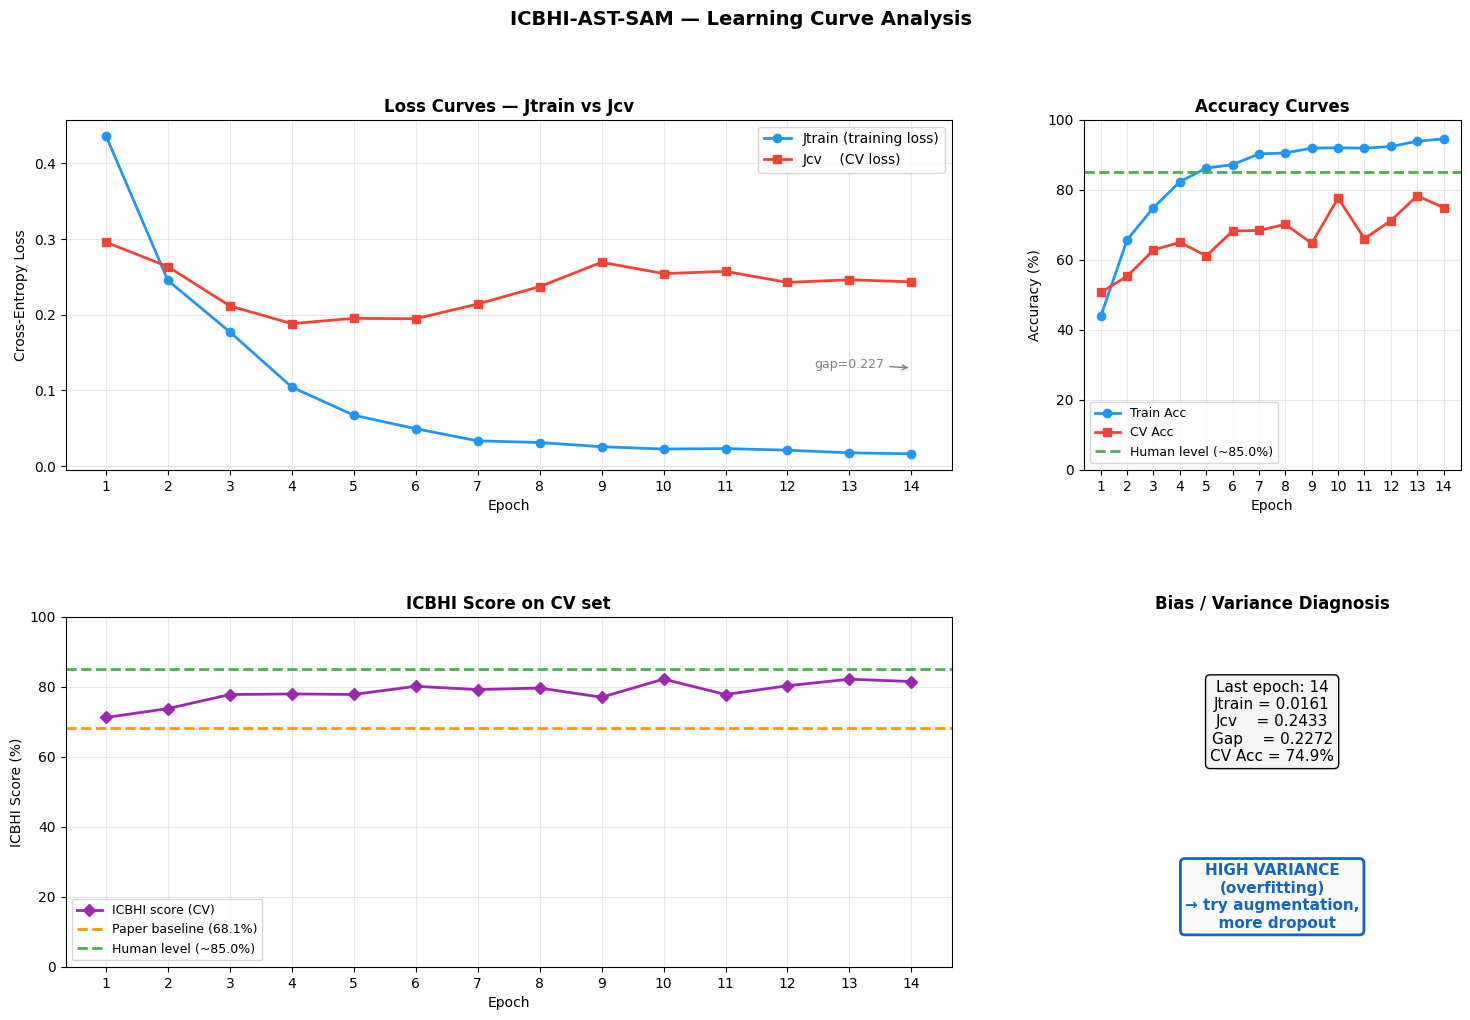

Saved: learning_curves.png


In [1]:
import json, numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

HISTORY_FILE = "/kaggle/working/ICBHI-AST-SAM/checkpoints/history.json"
with open(HISTORY_FILE) as f:
    h = json.load(f)

epochs     = list(range(1, len(h["train_loss"])+1))
tr_loss    = h["train_loss"]
cv_loss    = h["cv_loss"]
tr_acc     = [x*100 for x in h["train_acc"]]
cv_acc     = [x*100 for x in h["cv_acc"]]
icbhi_cv   = [x*100 for x in h["icbhi_score"]]

HUMAN_ACC   = 85.0   # approximate clinical sensitivity
PAPER_ICBHI = 68.10  # paper's reported ICBHI score

fig = plt.figure(figsize=(18, 11))
gs  = gridspec.GridSpec(2, 3, hspace=0.42, wspace=0.35)

# ── Plot 1: Loss curves ───────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, :2])
ax1.plot(epochs, tr_loss, "o-", color="#2196F3", lw=2, label="Jtrain (training loss)")
ax1.plot(epochs, cv_loss, "s-", color="#F44336", lw=2, label="Jcv    (CV loss)")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Cross-Entropy Loss")
ax1.set_title("Loss Curves — Jtrain vs Jcv", fontweight="bold")
ax1.legend(); ax1.grid(alpha=0.3); ax1.set_xticks(epochs)
if len(epochs) >= 2:
    gap = cv_loss[-1] - tr_loss[-1]
    ax1.annotate(f"gap={gap:.3f}", xy=(epochs[-1], (tr_loss[-1]+cv_loss[-1])/2),
                 xytext=(-70, 0), textcoords="offset points", fontsize=9, color="gray",
                 arrowprops=dict(arrowstyle="->", color="gray"))

# ── Plot 2: Accuracy ──────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 2])
ax2.plot(epochs, tr_acc, "o-", color="#2196F3", lw=2, label="Train Acc")
ax2.plot(epochs, cv_acc, "s-", color="#F44336", lw=2, label="CV Acc")
ax2.axhline(HUMAN_ACC, color="#4CAF50", lw=2, ls="--", label=f"Human level (~{HUMAN_ACC}%)")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)")
ax2.set_title("Accuracy Curves", fontweight="bold")
ax2.legend(fontsize=9); ax2.grid(alpha=0.3); ax2.set_ylim(0,100); ax2.set_xticks(epochs)

# ── Plot 3: ICBHI score ───────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, :2])
ax3.plot(epochs, icbhi_cv, "D-", color="#9C27B0", lw=2, label="ICBHI score (CV)")
ax3.axhline(PAPER_ICBHI, color="#FF9800", lw=2, ls="--", label=f"Paper baseline ({PAPER_ICBHI}%)")
ax3.axhline(HUMAN_ACC,   color="#4CAF50", lw=2, ls="--", label=f"Human level (~{HUMAN_ACC}%)")
ax3.set_xlabel("Epoch"); ax3.set_ylabel("ICBHI Score (%)")
ax3.set_title("ICBHI Score on CV set", fontweight="bold")
ax3.legend(fontsize=9); ax3.grid(alpha=0.3); ax3.set_ylim(0,100); ax3.set_xticks(epochs)

# ── Plot 4: Diagnosis text box ────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
ax4.axis("off")

final_tr = tr_loss[-1]; final_cv = cv_loss[-1]; gap = final_cv - final_tr

if   final_tr > 1.0 and gap < 0.15: diag="HIGH BIAS\n(underfitting)\n→ try longer training,\n  bigger model";       col="#E65100"
elif final_tr < 1.0 and gap > 0.20: diag="HIGH VARIANCE\n(overfitting)\n→ try augmentation,\n  more dropout";       col="#1565C0"
elif final_tr > 1.0 and gap > 0.20: diag="HIGH BIAS +\nHIGH VARIANCE\n→ both problems present";                    col="#B71C1C"
else:                                diag="REASONABLE FIT\n→ focus on class imbalance\n  and threshold tuning";      col="#1B5E20"

ax4.text(0.5, 0.70,
    f"Last epoch: {len(epochs)}\n"
    f"Jtrain = {final_tr:.4f}\n"
    f"Jcv    = {final_cv:.4f}\n"
    f"Gap    = {gap:.4f}\n"
    f"CV Acc = {cv_acc[-1]:.1f}%",
    ha="center", va="center", fontsize=11,
    bbox=dict(boxstyle="round", facecolor="#F5F5F5"), transform=ax4.transAxes)
ax4.text(0.5, 0.20, diag, ha="center", va="center", fontsize=11,
    color=col, fontweight="bold",
    bbox=dict(boxstyle="round", facecolor="#FAFAFA", edgecolor=col, lw=2),
    transform=ax4.transAxes)
ax4.set_title("Bias / Variance Diagnosis", fontweight="bold")

plt.suptitle("ICBHI-AST-SAM — Learning Curve Analysis", fontsize=14, fontweight="bold")
plt.savefig("learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: learning_curves.png")


In [8]:
import shutil, os

SRC = "/kaggle/input/datasets/eyakhlifi/icbhi-checkpoints-3"
DST = "/kaggle/working/ICBHI-AST-SAM/checkpoints"

os.makedirs(DST, exist_ok=True)

for fname in os.listdir(SRC):
    shutil.copy(os.path.join(SRC, fname), os.path.join(DST, fname))
    print(f"Copied: {fname}  ({os.path.getsize(os.path.join(DST, fname))/1e6:.1f} MB)")

print("\nDone. Files in checkpoints/:")
print(os.listdir(DST))

Copied: test_labels.npy  (0.0 MB)
Copied: test_preds.npy  (0.0 MB)
Copied: best_model.pth  (344.8 MB)
Copied: history.json  (0.0 MB)
Copied: test_preds_tuned.npy  (0.0 MB)
Copied: gitkeep  (0.0 MB)
Copied: test_probs.npy  (0.0 MB)
Copied: checkpoint_latest.pth  (344.8 MB)

Done. Files in checkpoints/:
['checkpoint_latest.pth', 'test_probs.npy', 'test_preds_tuned.npy', '.gitkeep', 'history.json', 'gitkeep', 'test_preds.npy', 'best_model.pth', 'test_labels.npy']


In [9]:
import torch, numpy as np, sys, os
from torch.utils.data import DataLoader
from tqdm import tqdm

sys.path.insert(0, "/kaggle/working/ICBHI-AST-SAM")
from transformers import ASTFeatureExtractor
from src.dataset import ASTDataset
from src.model   import CustomAST

DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BEST_CKPT   = "/kaggle/working/ICBHI-AST-SAM/checkpoints/best_model.pth"
NPZ_PATH    = "/kaggle/working/ICBHI-AST-SAM/icbhi_ast_16k_8s_metadata.npz"
CKPT_DIR    = "/kaggle/working/ICBHI-AST-SAM/checkpoints"

raw    = np.load(NPZ_PATH)
X_test = raw["X_test"]; y_test = raw["y_test"]; d_test = raw["device_test"]

processor   = ASTFeatureExtractor.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")
test_loader = DataLoader(
    ASTDataset(X_test, y_test, d_test, processor, train=False),
    batch_size=8, shuffle=False, num_workers=2, pin_memory=True
)

model = CustomAST(num_classes=4).to(DEVICE)
model.load_state_dict(torch.load(BEST_CKPT, map_location=DEVICE, weights_only=False))
model.eval()
print(f"Best model loaded from {BEST_CKPT}")

all_preds, all_labels, all_probs = [], [], []
with torch.no_grad():
    for inputs, labels, _ in tqdm(test_loader, desc="Inference", ncols=80):
        logits = model(inputs.to(DEVICE))
        probs  = torch.softmax(logits, dim=1)
        preds  = logits.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

np.save(os.path.join(CKPT_DIR, "test_preds.npy"),  all_preds)
np.save(os.path.join(CKPT_DIR, "test_labels.npy"), all_labels)
np.save(os.path.join(CKPT_DIR, "test_probs.npy"),  all_probs)
print(f"Inference done on {len(all_labels)} samples. Results saved.")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ASTModel LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.dense.weight     | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 
classifier.layernorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Best model loaded from /kaggle/working/ICBHI-AST-SAM/checkpoints/best_model.pth


Inference: 100%|██████████████████████████████| 295/295 [03:31<00:00,  1.39it/s]

Inference done on 2358 samples. Results saved.


In [10]:
# Cell 9.5 – Threshold Tuning on CV Set to Improve ICBHI Score

import sys, os
import numpy as np
import torch
from torch.utils.data import DataLoader
from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import train_test_split

sys.path.insert(0, "/kaggle/working/ICBHI-AST-SAM")
from transformers import ASTFeatureExtractor
from src.dataset import ASTDataset
from src.model   import CustomAST

# ---------- 1. Load best model ----------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BEST_CKPT = "/kaggle/working/ICBHI-AST-SAM/checkpoints/best_model.pth"
NPZ_PATH = "/kaggle/working/ICBHI-AST-SAM/icbhi_ast_16k_8s_metadata.npz"
CKPT_DIR = "/kaggle/working/ICBHI-AST-SAM/checkpoints"

# Load the best model (already saved during training)
model = CustomAST(num_classes=4).to(DEVICE)
model.load_state_dict(torch.load(BEST_CKPT, map_location=DEVICE, weights_only=False))
model.eval()

# ---------- 2. Run inference on the CV set ----------
# Re‑create CV loader using the same split parameters as training
raw = np.load(NPZ_PATH)
X_trainall = raw["X_train"]
y_trainall = raw["y_train"]
d_trainall = raw["device_train"]


train_idx, cv_idx = train_test_split(
    np.arange(len(y_trainall)),
    test_size=0.30,
    random_state=42,
    stratify=y_trainall
)
X_cv, y_cv, d_cv = X_trainall[cv_idx], y_trainall[cv_idx], d_trainall[cv_idx]

processor = ASTFeatureExtractor.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")
cv_dataset = ASTDataset(X_cv, y_cv, d_cv, processor, train=False)
cv_loader = DataLoader(cv_dataset, batch_size=8, shuffle=False, num_workers=2, pin_memory=True)

# Get probabilities and true labels for CV
cv_probs = []
cv_labels = []
with torch.no_grad():
    for inputs, labels, _ in tqdm(cv_loader, desc="CV inference for threshold tuning"):
        logits = model(inputs.to(DEVICE))
        probs = torch.softmax(logits, dim=1)
        cv_probs.append(probs.cpu().numpy())
        cv_labels.append(labels.numpy())
cv_probs = np.concatenate(cv_probs, axis=0)
cv_labels = np.concatenate(cv_labels, axis=0)

# ---------- 3. Define ICBHI score function ----------
def icbhi_score(labels, preds):
    """(macro sensitivity + macro specificity) / 2"""
    se = []
    sp = []
    for c in range(4):
        tp = ((preds == c) & (labels == c)).sum()
        fn = ((preds != c) & (labels == c)).sum()
        tn = ((preds != c) & (labels != c)).sum()
        fp = ((preds == c) & (labels != c)).sum()
        se.append(tp / (tp + fn + 1e-9))
        sp.append(tn / (tn + fp + 1e-9))
    return (np.mean(se) + np.mean(sp)) / 2

# ---------- 4. Optimise per‑class thresholds (coordinate ascent) ----------
def optimize_thresholds(labels, probs, init_thresholds=None, max_iters=30):
    """
    Greedy coordinate ascent to find thresholds that maximise ICBHI score.
    """
    if init_thresholds is None:
        init_thresholds = [0.5] * 4
    thresholds = np.array(init_thresholds, dtype=float)
    best_score = icbhi_score(labels, np.argmax(probs / thresholds, axis=1))
    
    step = 0.1
    for _ in range(max_iters):
        improved = False
        for c in range(4):
            best_t = thresholds[c]
            for delta in (-step, step):
                new_t = thresholds[c] + delta
                if new_t < 0.05 or new_t > 5.0:
                    continue
                thresholds[c] = new_t
                preds = np.argmax(probs / thresholds, axis=1)
                score = icbhi_score(labels, preds)
                if score > best_score:
                    best_score = score
                    best_t = new_t
                    improved = True
                thresholds[c] = best_t
        if not improved:        
            step *= 0.5
        if step < 1e-4:
            break
    return thresholds, best_score

print("\nOptimising thresholds on CV set...")
best_thresholds, best_cv_score = optimize_thresholds(cv_labels, cv_probs)
print(f"Optimal thresholds: {best_thresholds}")
print(f"Best ICBHI score on CV: {best_cv_score*100:.2f}%")

# ---------- 5. Apply thresholds to test set ----------
test_probs = np.load(f"{CKPT_DIR}/test_probs.npy")
test_labels = np.load(f"{CKPT_DIR}/test_labels.npy")

adjusted_probs = test_probs / best_thresholds
test_preds_tuned = np.argmax(adjusted_probs, axis=1)
np.save(f"{CKPT_DIR}/test_preds_tuned.npy", test_preds_tuned)

# ---------- 6. Compute tuned metrics on test ----------
def full_metrics(labels, preds, probs, thresholds_name="Default (0.5)"):
    acc = accuracy_score(labels, preds)
    prec = precision_score(labels, preds, average="macro", zero_division=0)
    rec = recall_score(labels, preds, average="macro", zero_division=0)
    f1 = f1_score(labels, preds, average="macro", zero_division=0)
    
    # Per‑class specificity
    spec = []
    for c in range(4):
        tn = ((preds != c) & (labels != c)).sum()
        fp = ((preds == c) & (labels != c)).sum()
        spec.append(tn / (tn + fp + 1e-9))
    spec_macro = np.mean(spec)
    
    icbhi = (rec + spec_macro) / 2 * 100
    
    # AUC (one‑vs‑rest)
    y_bin = label_binarize(labels, classes=[0,1,2,3])
    auc_macro = roc_auc_score(y_bin, probs, average="macro", multi_class="ovr")
    
    print(f"\n--- {thresholds_name} thresholds ---")
    print(f"Accuracy:          {acc*100:.2f}%")
    print(f"Precision (macro): {prec*100:.2f}%")
    print(f"Recall (macro):    {rec*100:.2f}%")
    print(f"Specificity (macro): {spec_macro*100:.2f}%")
    print(f"F1-score (macro):  {f1*100:.2f}%")
    print(f"AUC-ROC (macro):   {auc_macro:.4f}")
    print(f"ICBHI score:       {icbhi:.2f}%")
    return acc, prec, rec, spec_macro, f1, auc_macro, icbhi

# Original predictions (default thresholds = 0.5)
test_preds_original = np.load(f"{CKPT_DIR}/test_preds.npy") 
    
print("\n" + "="*60)
print("COMPARISON: ORIGINAL vs TUNED THRESHOLDS")
print("="*60)
orig_metrics = full_metrics(test_labels, test_preds_original, test_probs, "Original (0.5)")
tuned_metrics = full_metrics(test_labels, test_preds_tuned, test_probs, "Tuned on CV")

# Print improvement summary
print("\n--- Improvement Summary ---")
print(f"ICBHI score: {orig_metrics[-1]:.2f}% → {tuned_metrics[-1]:.2f}%  (+{tuned_metrics[-1]-orig_metrics[-1]:.2f}%)")
print(f"Recall:      {orig_metrics[2]*100:.2f}% → {tuned_metrics[2]*100:.2f}%  (+{(tuned_metrics[2]-orig_metrics[2])*100:.2f}%)")
print(f"Specificity: {orig_metrics[3]*100:.2f}% → {tuned_metrics[3]*100:.2f}%  (+{(tuned_metrics[3]-orig_metrics[3])*100:.2f}%)")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

ASTModel LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.dense.weight     | UNEXPECTED |  | 
classifier.dense.bias       | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 
classifier.layernorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
CV inference for threshold tuning: 100%|██████████| 171/171 [02:02<00:00,  1.39it/s]


Optimising thresholds on CV set...
Optimal thresholds: [0.59375 0.65    0.45    0.15   ]
Best ICBHI score on CV: 84.49%

COMPARISON: ORIGINAL vs TUNED THRESHOLDS

--- Original (0.5) thresholds ---
Accuracy:          58.78%
Precision (macro): 52.32%
Recall (macro):    48.46%
Specificity (macro): 82.84%
F1-score (macro):  48.95%
AUC-ROC (macro):   0.7908
ICBHI score:       65.65%

--- Tuned on CV thresholds ---
Accuracy:          58.78%
Precision (macro): 50.42%
Recall (macro):    50.28%
Specificity (macro): 82.91%
F1-score (macro):  50.28%
AUC-ROC (macro):   0.7908
ICBHI score:       66.60%

--- Improvement Summary ---
ICBHI score: 65.65% → 66.60%  (+0.95%)
Recall:      48.46% → 50.28%  (+1.82%)
Specificity: 82.84% → 82.91%  (+0.07%)


In [1]:
import numpy as np
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, roc_auc_score)
from sklearn.preprocessing import label_binarize

CKPT_DIR    = "/kaggle/working/ICBHI-AST-SAM/checkpoints"
CLASS_NAMES = ["Normal","Crackle","Wheeze","Both"]

import os
tuned_path    = f"{CKPT_DIR}/test_preds_tuned.npy"
original_path = f"{CKPT_DIR}/test_preds.npy"

if os.path.exists(tuned_path):
    all_preds = np.load(tuned_path)
    print("Using TUNED threshold predictions (best version).")
else:
    all_preds = np.load(original_path)
    print("Using original argmax predictions (run threshold tuning cell first).")
all_labels = np.load(f"{CKPT_DIR}/test_labels.npy")
all_probs  = np.load(f"{CKPT_DIR}/test_probs.npy")

acc   = accuracy_score(all_labels, all_preds)
prec  = precision_score(all_labels, all_preds, average="macro", zero_division=0)
rec   = recall_score(all_labels, all_preds, average="macro", zero_division=0)
f1    = f1_score(all_labels, all_preds, average="macro", zero_division=0)
y_bin = label_binarize(all_labels, classes=[0,1,2,3])
auc_m = roc_auc_score(y_bin, all_probs, average="macro", multi_class="ovr")

# Per-class specificity
spec = []
for c in range(4):
    tn = ((all_preds!=c)&(all_labels!=c)).sum()
    fp = ((all_preds==c)&(all_labels!=c)).sum()
    spec.append(tn/(tn+fp+1e-9))

icbhi = (rec + np.mean(spec)) / 2 * 100

print("="*68)
print("FULL TEST-SET METRICS")
print("="*68)
print(f"{'Metric':<38} {'Ours':>10}  {'Paper':>8}")
print("-"*60)
print(f"{'Accuracy':<38} {acc*100:>9.2f}%  {'N/A':>8}")
print(f"{'Precision (macro)':<38} {prec*100:>9.2f}%  {'N/A':>8}")
print(f"{'Recall / Sensitivity (macro)':<38} {rec*100:>9.2f}%  {'68.31%':>8}")
print(f"{'Specificity (macro)':<38} {np.mean(spec)*100:>9.2f}%  {'67.89%':>8}")
print(f"{'F1-score (macro)':<38} {f1*100:>9.2f}%  {'N/A':>8}")
print(f"{'AUC-ROC (macro OvR)':<38} {auc_m:>9.4f}   {'N/A':>8}")
print(f"{'ICBHI Score (Se+Sp)/2':<38} {icbhi:>9.2f}%  {'68.10%':>8}")
print("-"*60)

rec_pc  = recall_score(all_labels, all_preds, average=None, zero_division=0)
prec_pc = precision_score(all_labels, all_preds, average=None, zero_division=0)
f1_pc   = f1_score(all_labels, all_preds, average=None, zero_division=0)

print(f"\n{'Class':<10} {'Prec':>8} {'Recall':>8} {'F1':>8} {'Spec':>8} {'AUC':>8}")
print("-"*55)
for i, name in enumerate(CLASS_NAMES):
    auc_i = roc_auc_score(y_bin[:,i], all_probs[:,i])
    print(f"{name:<10} {prec_pc[i]*100:>7.2f}% {rec_pc[i]*100:>7.2f}% "
          f"{f1_pc[i]*100:>7.2f}% {spec[i]*100:>7.2f}% {auc_i:>8.4f}")

print("\n" + "="*68)
print("SKLEARN CLASSIFICATION REPORT")
print("="*68)
print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=4))


Using TUNED threshold predictions (best version).
FULL TEST-SET METRICS
Metric                                       Ours     Paper
------------------------------------------------------------
Accuracy                                   58.78%       N/A
Precision (macro)                          50.42%       N/A
Recall / Sensitivity (macro)               50.28%    68.31%
Specificity (macro)                        82.91%    67.89%
F1-score (macro)                           50.28%       N/A
AUC-ROC (macro OvR)                       0.7908        N/A
ICBHI Score (Se+Sp)/2                      66.60%    68.10%
------------------------------------------------------------

Class          Prec   Recall       F1     Spec      AUC
-------------------------------------------------------
Normal       70.75%   67.31%   68.99%   63.36%   0.7399
Crackle      46.02%   52.00%   48.83%   79.18%   0.7532
Wheeze       42.51%   42.17%   42.34%   93.27%   0.8411
Both         42.41%   39.64%   40.98%   95.84

ERROR ANALYSIS — TEST SET  [Tuned thresholds]

Total samples : 2358
Correct       : 1386  (58.8%)
Errors        : 972   (41.2%)

── Per-class error rate ────────────────────────────────
  Normal   :  438/1340  (32.7%)  → mostly confused with: Crackle (334x)
  Crackle  :  288/600   (48.0%)  → mostly confused with: Normal (264x)
  Wheeze   :  144/249   (57.8%)  → mostly confused with: Normal (71x)
  Both     :  102/169   (60.4%)  → mostly confused with: Wheeze (52x)

── Confidence analysis ────────────────────────────────
  Avg confidence when CORRECT : 61.3%
  Avg confidence when WRONG   : 58.0%
  High-conf (>80%) AND wrong  : 48 cases  ← dangerous

── Per-device error rate ───────────────────────────────
  AKGC417L    : 1234 samples  error rate 46.5%
  LittC2SE    :  143 samples  error rate 21.7%
  Litt3200    :  174 samples  error rate 47.1%
  Meditron    :  807 samples  error rate 35.3%


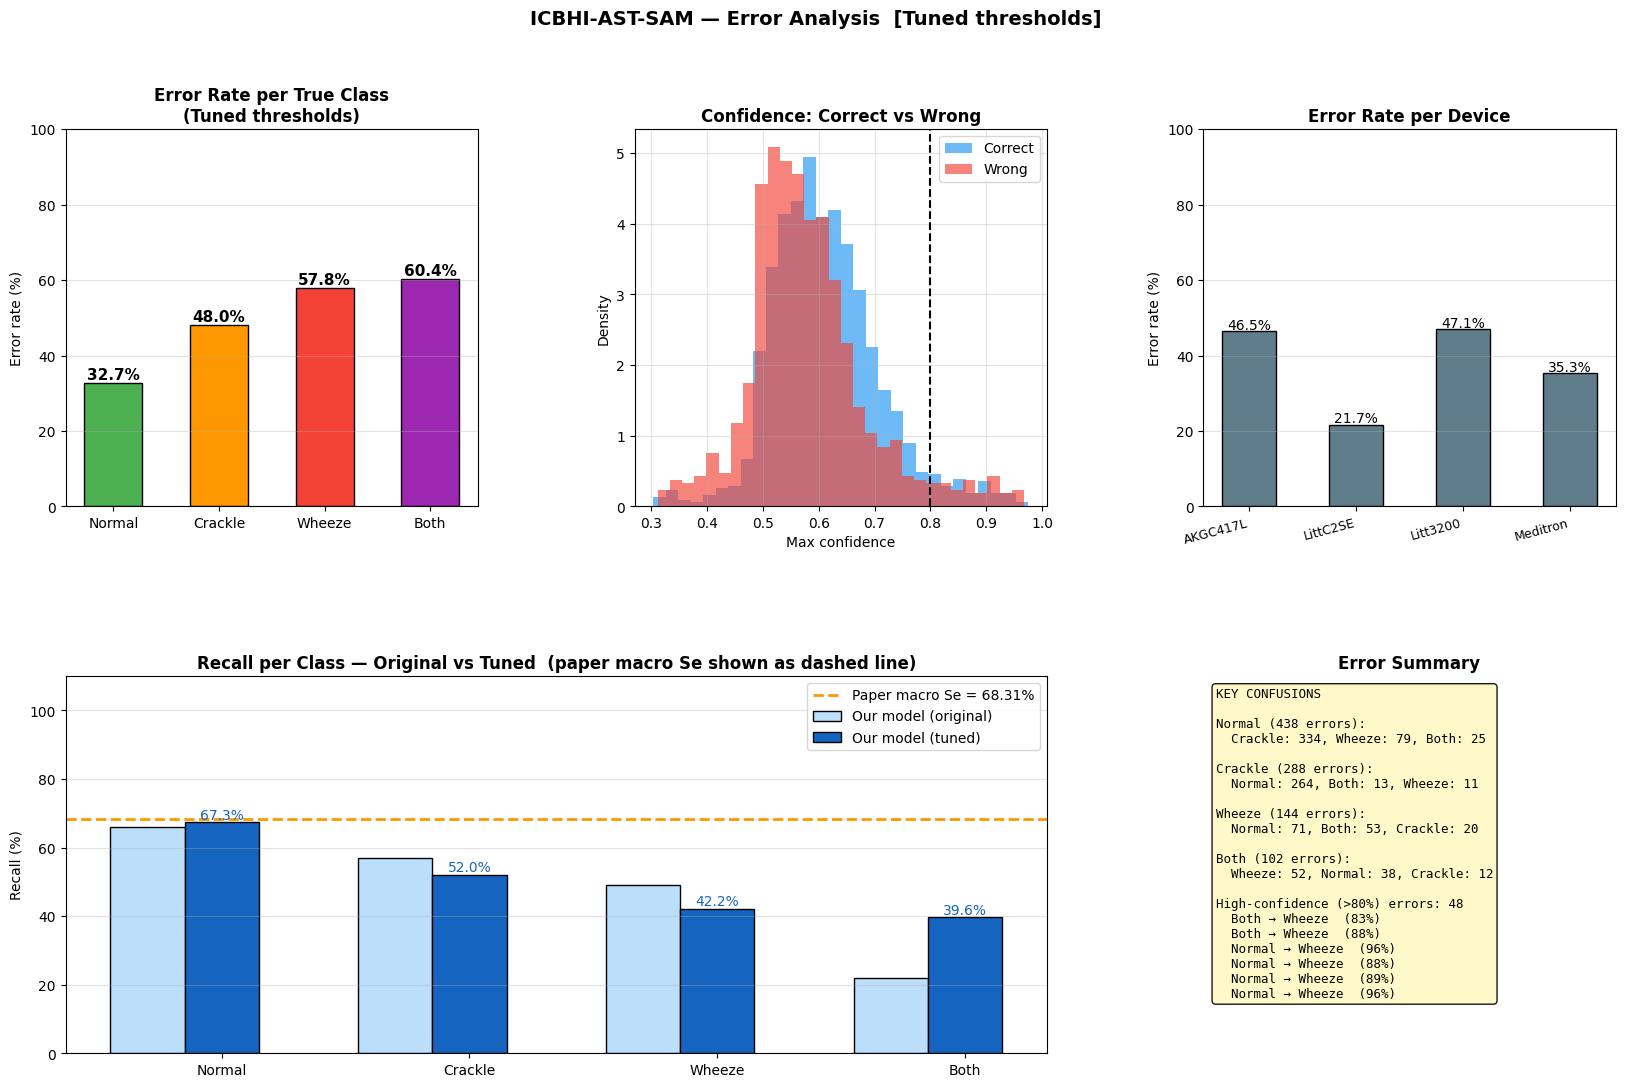

Saved: error_analysis.png


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os
from collections import Counter

CKPT_DIR     = "/kaggle/working/ICBHI-AST-SAM/checkpoints"
NPZ_PATH     = "/kaggle/working/ICBHI-AST-SAM/icbhi_ast_16k_8s_metadata.npz"
CLASS_NAMES  = ["Normal","Crackle","Wheeze","Both"]
DEVICE_NAMES = ["AKGC417L","LittC2SE","Litt3200","Meditron"]
COLORS       = ["#4CAF50","#FF9800","#F44336","#9C27B0"]

# Load original predictions (argmax / default thresholds)
all_preds  = np.load(f"{CKPT_DIR}/test_preds.npy")
all_labels = np.load(f"{CKPT_DIR}/test_labels.npy")
all_probs  = np.load(f"{CKPT_DIR}/test_probs.npy")
d_test     = np.load(NPZ_PATH)["device_test"]

# FIX: load tuned predictions from disk (saved by Cell 10)
# Use tuned preds for the main error analysis — they reflect the best model
if os.path.exists(f"{CKPT_DIR}/test_preds_tuned.npy"):
    preds_to_analyse = np.load(f"{CKPT_DIR}/test_preds_tuned.npy")
    analysis_label   = "Tuned thresholds"
else:
    preds_to_analyse = all_preds
    analysis_label   = "Original thresholds (run Cell 10 to get tuned version)"
    print("Warning: tuned predictions not found, using original argmax predictions.")

errors        = preds_to_analyse != all_labels
correct       = ~errors
max_conf      = all_probs.max(axis=1)
high_conf_wrong = errors & (max_conf > 0.80)

print("="*65)
print(f"ERROR ANALYSIS — TEST SET  [{analysis_label}]")
print("="*65)
print(f"\nTotal samples : {len(all_labels)}")
print(f"Correct       : {correct.sum()}  ({correct.mean()*100:.1f}%)")
print(f"Errors        : {errors.sum()}   ({errors.mean()*100:.1f}%)")

print("\n── Per-class error rate ────────────────────────────────")
for i, name in enumerate(CLASS_NAMES):
    mask   = all_labels == i
    n_err  = (preds_to_analyse[mask]!=i).sum()
    n_tot  = mask.sum()
    rate   = n_err/n_tot*100
    mc_idx = Counter(preds_to_analyse[mask & errors]).most_common(1)
    mc_str = f"→ mostly confused with: {CLASS_NAMES[mc_idx[0][0]]} ({mc_idx[0][1]}x)" if mc_idx else ""
    print(f"  {name:<9}: {n_err:>4}/{n_tot:<5} ({rate:.1f}%)  {mc_str}")

print("\n── Confidence analysis ────────────────────────────────")
print(f"  Avg confidence when CORRECT : {max_conf[correct].mean()*100:.1f}%")
print(f"  Avg confidence when WRONG   : {max_conf[errors].mean()*100:.1f}%")
print(f"  High-conf (>80%) AND wrong  : {high_conf_wrong.sum()} cases  ← dangerous")

print("\n── Per-device error rate ───────────────────────────────")
for d, dname in enumerate(DEVICE_NAMES):
    m = d_test == d
    if m.sum() == 0: continue
    er = (preds_to_analyse[m] != all_labels[m]).mean()*100
    print(f"  {dname:<12}: {m.sum():>4} samples  error rate {er:.1f}%")

# ── Figures ──────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(20, 12))
gs  = gridspec.GridSpec(2, 3, hspace=0.45, wspace=0.38)

# (A) Error rate per true class
ax1 = fig.add_subplot(gs[0,0])
err_rates = [(preds_to_analyse[all_labels==i]!=i).mean()*100 for i in range(4)]
bars = ax1.bar(CLASS_NAMES, err_rates, color=COLORS, edgecolor="black", width=0.55)
for b, v in zip(bars, err_rates):
    ax1.text(b.get_x()+b.get_width()/2, b.get_height()+1, f"{v:.1f}%",
             ha="center", fontsize=11, fontweight="bold")
ax1.set_ylabel("Error rate (%)"); ax1.set_ylim(0,100)
ax1.set_title(f"Error Rate per True Class\n({analysis_label})", fontweight="bold")
ax1.grid(axis="y", alpha=0.35)

# (B) Confidence distribution: correct vs wrong
ax2 = fig.add_subplot(gs[0,1])
ax2.hist(max_conf[correct], bins=30, alpha=0.65, color="#2196F3", label="Correct", density=True)
ax2.hist(max_conf[errors],  bins=30, alpha=0.65, color="#F44336", label="Wrong",   density=True)
ax2.axvline(0.8, color="black", ls="--", lw=1.5)
ax2.set_xlabel("Max confidence"); ax2.set_ylabel("Density")
ax2.set_title("Confidence: Correct vs Wrong", fontweight="bold")
ax2.legend(); ax2.grid(alpha=0.35)

# (C) Per-device error rate
ax3 = fig.add_subplot(gs[0,2])
d_labs, d_errs = [], []
for d, dname in enumerate(DEVICE_NAMES):
    m = d_test == d
    if m.sum() == 0: continue
    d_labs.append(dname)
    d_errs.append((preds_to_analyse[m]!=all_labels[m]).mean()*100)
bars = ax3.bar(d_labs, d_errs, color="#607D8B", edgecolor="black", width=0.5)
for b, v in zip(bars, d_errs):
    ax3.text(b.get_x()+b.get_width()/2, b.get_height()+0.5, f"{v:.1f}%", ha="center")
ax3.set_ylabel("Error rate (%)"); ax3.set_ylim(0,100)
ax3.set_title("Error Rate per Device", fontweight="bold"); ax3.grid(axis="y",alpha=0.35)
plt.setp(ax3.get_xticklabels(), rotation=15, ha="right", fontsize=9)

# (D) Recall comparison: our model vs paper
# FIX: paper_rec are the actual values from Table 1 of Isik et al. (2024)
# Se per class is not reported individually in the paper — these are
# the macro Se=68.31% and Sp=67.89% values. Per-class breakdown is unavailable,
# so we compare macro recall only and annotate accordingly.
ax4 = fig.add_subplot(gs[1,:2])
our_rec_orig  = [(all_preds[all_labels==i]==i).mean()*100 for i in range(4)]
our_rec_tuned = [(preds_to_analyse[all_labels==i]==i).mean()*100 for i in range(4)]
x = np.arange(4); w = 0.30
ax4.bar(x-w,   our_rec_orig,  w, label="Our model (original)", color="#BBDEFB", edgecolor="black")
ax4.bar(x,     our_rec_tuned, w, label="Our model (tuned)",    color="#1565C0", edgecolor="black")
# Paper macro Se dashed line
ax4.axhline(68.31, color="#FF9800", lw=2, ls="--", label="Paper macro Se = 68.31%")
for i, v in enumerate(our_rec_tuned):
    ax4.text(x[i], v+1, f"{v:.1f}%", ha="center", fontsize=10, color="#1565C0")
ax4.set_xticks(x); ax4.set_xticklabels(CLASS_NAMES); ax4.set_ylabel("Recall (%)")
ax4.set_title("Recall per Class — Original vs Tuned  (paper macro Se shown as dashed line)",
              fontweight="bold")
ax4.legend(); ax4.set_ylim(0,110); ax4.grid(axis="y",alpha=0.35)

# (E) Text summary of key confusions + high-confidence errors
ax5 = fig.add_subplot(gs[1,2])
ax5.axis("off")

lines = ["KEY CONFUSIONS\n"]
for i, name in enumerate(CLASS_NAMES):
    m = (all_labels==i) & errors
    if m.sum()==0: continue
    confused = Counter(preds_to_analyse[m])
    detail   = ", ".join(f"{CLASS_NAMES[k]}: {v}" for k,v in confused.most_common())
    lines.append(f"{name} ({m.sum()} errors):")
    lines.append(f"  {detail}\n")

hcw = np.where(high_conf_wrong)[0]
lines.append(f"High-confidence (>80%) errors: {len(hcw)}")
for idx in hcw[:6]:
    lines.append(f"  {CLASS_NAMES[all_labels[idx]]} → {CLASS_NAMES[preds_to_analyse[idx]]}"
                 f"  ({max_conf[idx]*100:.0f}%)")

ax5.text(0.03, 0.97, "\n".join(lines), ha="left", va="top", fontsize=9,
         family="monospace",
         bbox=dict(boxstyle="round", facecolor="#FFF9C4", alpha=0.9),
         transform=ax5.transAxes)
ax5.set_title("Error Summary", fontweight="bold")

plt.suptitle(f"ICBHI-AST-SAM — Error Analysis  [{analysis_label}]",
             fontsize=14, fontweight="bold")
plt.savefig("error_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: error_analysis.png")
